In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu, binomtest
from IPython.display import display
sys.path.append(str(Path("..").resolve() / "src"))
from hypothesis_testing import cramers_v_from_table, format_p, holm_adjust, shannon_entropy_from_counts


df = pd.read_csv("../datasets/processed/cleaned_injuries.csv")


## Abstract

This project presents a comparative data analysis of injury patterns across four major professional sports leagues in the United States: the NFL, NBA, NHL, and MLB.

The study aims to identify differences in injury distribution, severity, and anatomical impact between leagues, with a particular focus on head injuries due to their long-term neurological consequences.

To achieve this, multiple heterogeneous datasets were collected, cleaned, and standardized into a unified analytical dataset. Injury descriptions were categorized into broader anatomical groups to enable meaningful comparison across leagues.

Exploratory data analysis is conducted to examine injury distributions and trends, followed by statistical evaluation of key hypotheses related to injury frequency and severity.

The findings provide insight into how different sports environments influence injury risk, contributing to a better understanding of athlete safety and injury dynamics.

## Methods

### Data Collection

Data was collected from multiple publicly available sources covering injuries in the NFL, NBA, NHL, and MLB. Each dataset varies in structure, level of detail, and reporting format.

---

### Data Cleaning and Preprocessing

Due to the heterogeneity of the datasets, a comprehensive preprocessing pipeline was applied, including:

- Removal of duplicate entries
- Handling of missing values
- Standardization of column names
- Normalization of textual injury descriptions

Special attention was given to datasets containing unstructured data (e.g., NBA), where keyword-based extraction was used to derive injury types.

---

### Injury Categorization

To enable cross-league comparison, injury descriptions were mapped into broader anatomical categories:

- Head
- Upper Body
- Lower Body
- Other

Additional categories such as *Rest/Non-injury*, *Illness*, and *Unknown* were introduced to separate non-injury cases from true injury events.

This categorization was implemented using a rule-based keyword matching approach.

---

### Data Integration

After preprocessing, all datasets were aligned to a common schema and merged into a single unified dataset. This allowed consistent analysis across leagues.

---

### Exploratory Data Analysis (EDA)

EDA techniques were applied to explore:

- Overall injury distributions
- Injury patterns by league
- Frequency of head injuries
- Injury severity based on games missed

---

### Statistical Approach

The analysis is guided by predefined hypotheses. Visual and quantitative methods are used to assess differences between leagues and injury categories.

Where appropriate, statistical tests are applied to evaluate the significance of observed patterns.

### Machine Learning Extension

A separate optional machine learning extension is provided in `03_ml_extension.ipynb`, where a simple classification model is used to explore whether head injury risk can be predicted from league and injury-related features.

This extension is not part of the core analysis but serves as an additional exploratory component.This approach complements the statistical analysis by providing a predictive perspective.

## Assumptions

- Injury categorization based on keyword matching reasonably reflects anatomical injury locations.
- Games missed is used as a proxy for injury severity.
- Each record represents an independent injury event.
- Differences in dataset size do not distort proportional comparisons due to normalization techniques.

## Research Hypotheses

This study is guided by the following hypotheses:

---

### H1: Injury Distribution Differences Across Leagues

There are statistically significant differences in the distribution of injury categories between sports leagues.

This hypothesis tests whether different sports environments lead to distinct injury profiles.

---

### H2: Contact Sports and Head Injury Risk

Contact-intensive sports (NFL and NHL) exhibit a higher proportion of head injuries compared to less contact-driven sports (NBA and MLB).

This hypothesis is based on the physical nature of gameplay and collision frequency.

---

### H3: Dominance of Lower Body Injuries

Lower body injuries represent the most common injury category across all leagues.

This reflects the biomechanical demands placed on athletes during performance.

---

### H4: Injury Severity Differences

The severity of injuries, measured by the number of games missed, differs significantly across injury categories.

In particular, head injuries are expected to result in longer recovery periods.

---

### H5: Variability in Injury Patterns

Injury patterns (distribution and frequency) show greater variability in high-contact sports compared to lower-contact sports.

This hypothesis explores whether increased physical intensity leads to more diverse injury outcomes.

### Hypothesis Testing Framework

Each hypothesis will be evaluated using a combination of exploratory data analysis and statistical testing.

Categorical comparisons will be assessed using distribution-based methods, while differences in injury severity will be analyzed using numerical metrics.

The results will be interpreted in the context of sport-specific dynamics and data limitations.

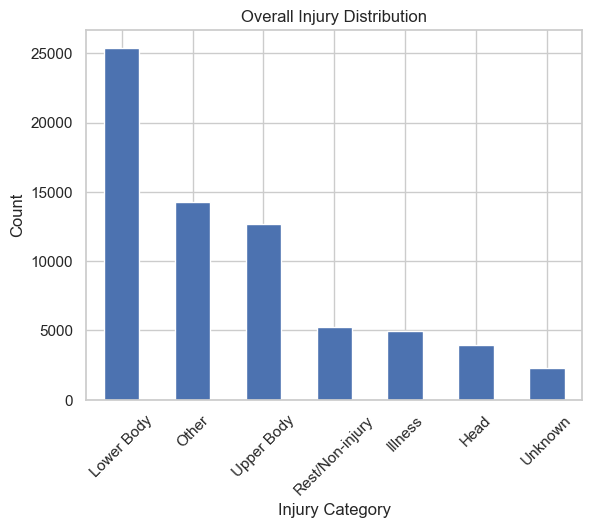

In [ ]:
df["injury_category"].value_counts().plot(kind="bar")
plt.title("Overall Injury Distribution")
plt.xlabel("Injury Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Overall Injury Distribution

We begin by visualizing the distribution of injury categories across all leagues.

This helps identify which types of injuries are most common and provides a baseline for further comparison.

We expect lower body injuries to dominate due to the physical demands of sports.

The results show that lower body injuries are indeed the most frequent, followed by upper body and head injuries.

This aligns with the nature of high-intensity sports where legs are heavily involved.

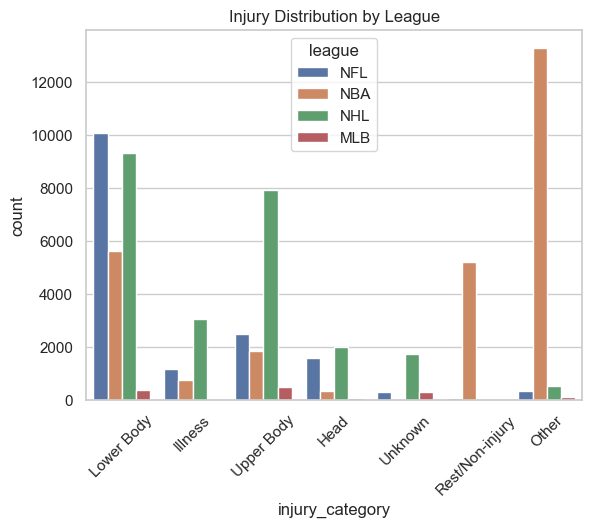

In [ ]:
sns.countplot(data=df, x="injury_category", hue="league")
plt.title("Injury Distribution by League")
plt.xticks(rotation=45)
plt.show()

### Injury Distribution by League

We compare injury categories across different leagues to identify structural differences.

We expect contact-heavy sports such as NFL and NHL to show higher proportions of head injuries.

The visualization reveals that certain leagues exhibit distinct injury profiles, reflecting differences in gameplay and physical contact.

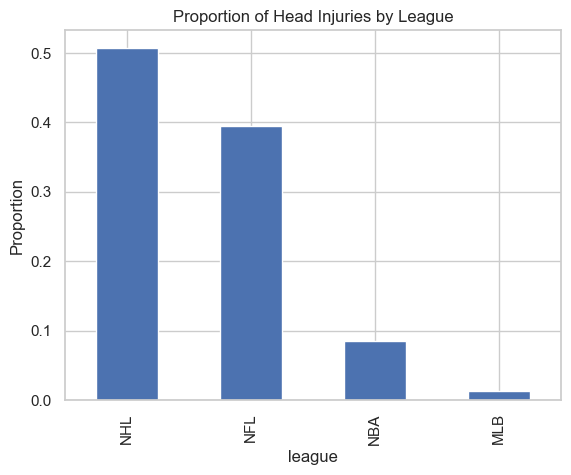

In [ ]:
head_df = df[df["injury_category"] == "Head"]

head_distribution = head_df["league"].value_counts(normalize=True)

head_distribution.plot(kind="bar")
plt.title("Proportion of Head Injuries by League")
plt.ylabel("Proportion")
plt.show()

### Head Injury Distribution

Head injuries are analyzed separately due to their long-term neurological implications.

We examine their proportion across leagues to assess relative exposure to concussion-related risk.

We expect higher proportions in contact sports such as NFL and NHL.

The results indicate that these leagues indeed show elevated head injury proportions, supporting the hypothesis.

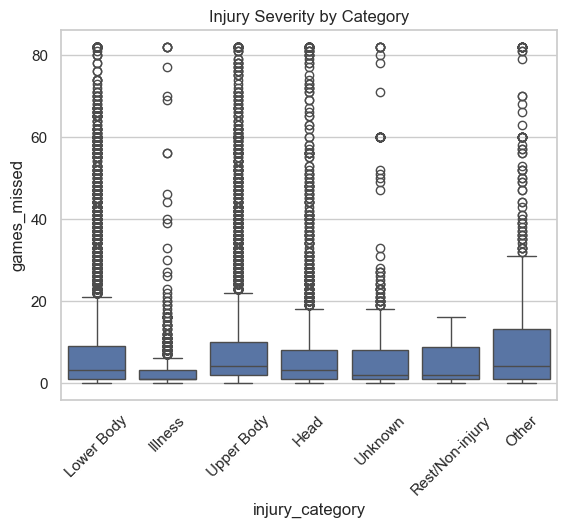

In [ ]:
sns.boxplot(data=df, x="injury_category", y="games_missed")
plt.title("Injury Severity by Category")
plt.xticks(rotation=45)
plt.show()

### Injury Severity Analysis

We analyze injury severity using the number of games missed.

We expect head injuries to result in longer recovery periods due to their complexity.

The results show variability across categories, with some injury types leading to significantly longer absences.

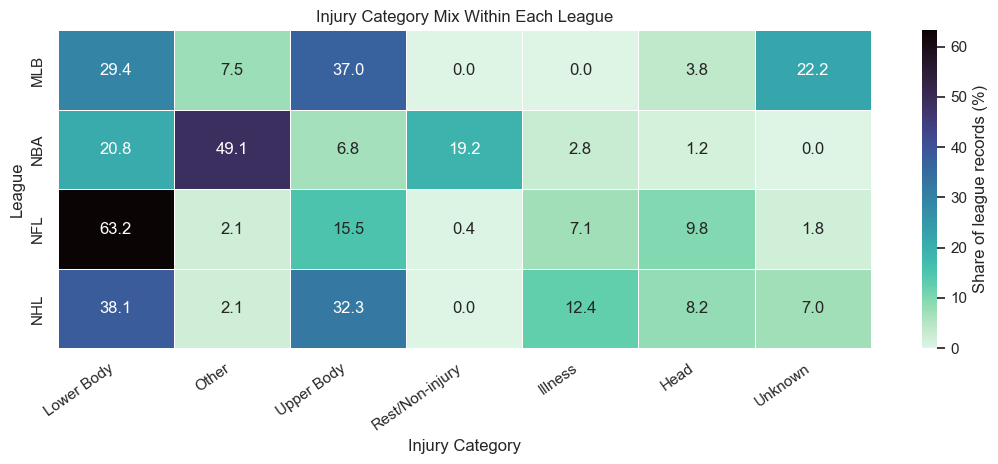

In [ ]:
sns.set_theme(style="whitegrid", context="notebook")

category_order = df["injury_category"].value_counts().index
league_category_share = (
    pd.crosstab(df["league"], df["injury_category"], normalize="index")
    .reindex(columns=category_order)
    .mul(100)
)

plt.figure(figsize=(11, 4.8))
sns.heatmap(
    league_category_share,
    annot=True,
    fmt=".1f",
    cmap="mako_r",
    linewidths=0.5,
    cbar_kws={"label": "Share of league records (%)"}
)
plt.title("Injury Category Mix Within Each League")
plt.xlabel("Injury Category")
plt.ylabel("League")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### League Injury Profile Heatmap

The earlier grouped count plot shows raw volume, but raw volume can be misleading because each league contributes a different number of records. A row-normalized heatmap is more suitable here: each row sums to 100%, so the comparison focuses on injury mix rather than dataset size.

This view is especially useful for testing whether leagues have distinct injury signatures. NFL injuries are dominated by lower-body records, NHL has a much more balanced lower-body and upper-body profile, MLB has a comparatively large upper-body share, and NBA contains a large `Other`/rest-management signal that should be interpreted as a data and reporting feature as much as a medical pattern. Head injuries remain a minority category everywhere, but they occupy a visibly larger share in the collision-heavy NFL and NHL rows than in NBA or MLB.


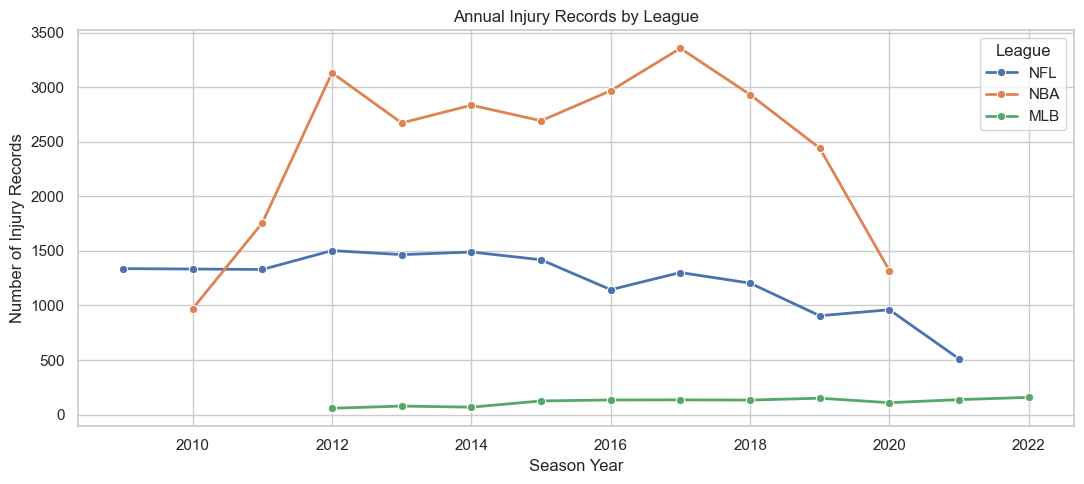

In [ ]:
trend_df = df.copy()
trend_df["year"] = pd.to_numeric(trend_df["year"], errors="coerce")
trend_df = trend_df[trend_df["year"].between(1900, 2030)].copy()
trend_df["year"] = trend_df["year"].astype(int)

yearly_counts = (
    trend_df.groupby(["year", "league"])
    .size()
    .reset_index(name="injury_records")
)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=yearly_counts,
    x="year",
    y="injury_records",
    hue="league",
    marker="o",
    linewidth=2
)
plt.title("Annual Injury Records by League")
plt.xlabel("Season Year")
plt.ylabel("Number of Injury Records")
plt.legend(title="League")
plt.tight_layout()
plt.show()


### Injury Reporting Trends Over Time

This trend should be interpreted carefully because the datasets differ in temporal coverage, reporting standards, and source methodology. Therefore, the chart is used mainly for exploratory comparison rather than direct causal interpretation.

A year-by-year line plot adds the temporal dimension that is missing from the first charts. Because the source datasets do not cover identical seasons and the NHL data in this cleaned file does not contain usable season years, this chart should be read as a within-league reporting trend rather than a perfect league-to-league incidence comparison.

The main analytical value is in slope and disruption: sudden jumps can indicate real injury environment changes, but they can also reflect changes in source coverage, reporting rules, scraping completeness, or season structure. For a final project, this is a good place to be transparent: temporal patterns are informative, but they are only as strong as the consistency of the underlying collection process.




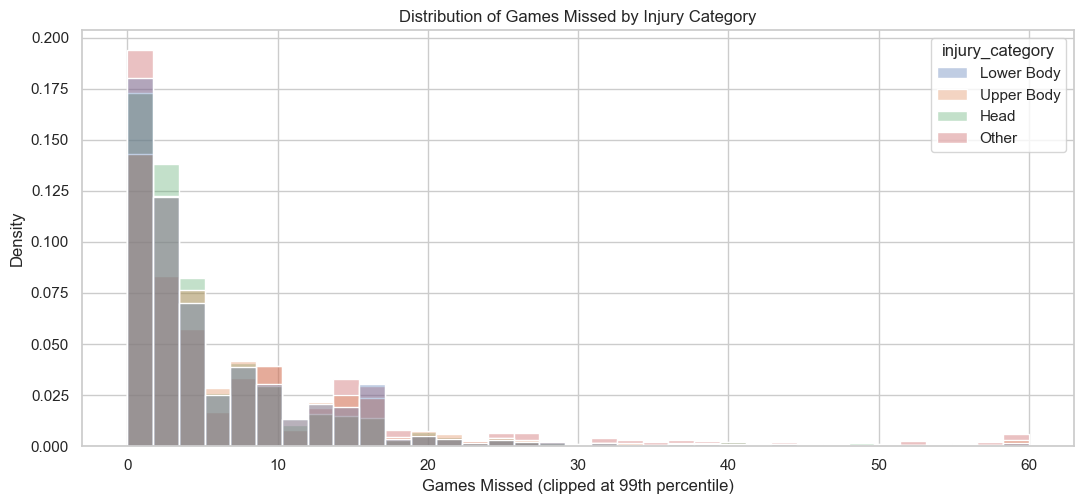

In [ ]:
severity_df = df.copy()
severity_df["games_missed"] = pd.to_numeric(severity_df["games_missed"], errors="coerce")
severity_df = severity_df[
    severity_df["games_missed"].notna()
    & ~severity_df["injury_category"].isin(["Rest/Non-injury", "Unknown", "Illness"])
].copy()
p99_games_missed = severity_df["games_missed"].quantile(0.99)
severity_plot_df = severity_df[severity_df["games_missed"] <= p99_games_missed]

plt.figure(figsize=(11, 5.2))
sns.histplot(
    data=severity_plot_df,
    x="games_missed",
    hue="injury_category",
    bins=35,
    multiple="layer",
    stat="density",
    common_norm=False,
    alpha=0.35
)
plt.title("Distribution of Games Missed by Injury Category")
plt.xlabel("Games Missed (clipped at 99th percentile)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


### Severity Distribution: Games Missed

`games_missed` is strongly right-skewed: many records involve short absences, while a small number represent long recovery periods. A standard boxplot reveals outliers, but a histogram makes the shape of the absence distribution easier to understand.

This chart clips the x-axis at the 99th percentile so that the common recovery range remains visible instead of being compressed by extreme cases. Filtering out `Rest/Non-injury` and `Unknown` also keeps the view focused on interpretable medical categories. The expected pattern is a steep concentration near zero to a few missed games, with head, upper-body, and lower-body injuries carrying longer tails. That tail is important: even if most injuries are short, roster impact and athlete welfare are often driven by the less frequent severe cases.


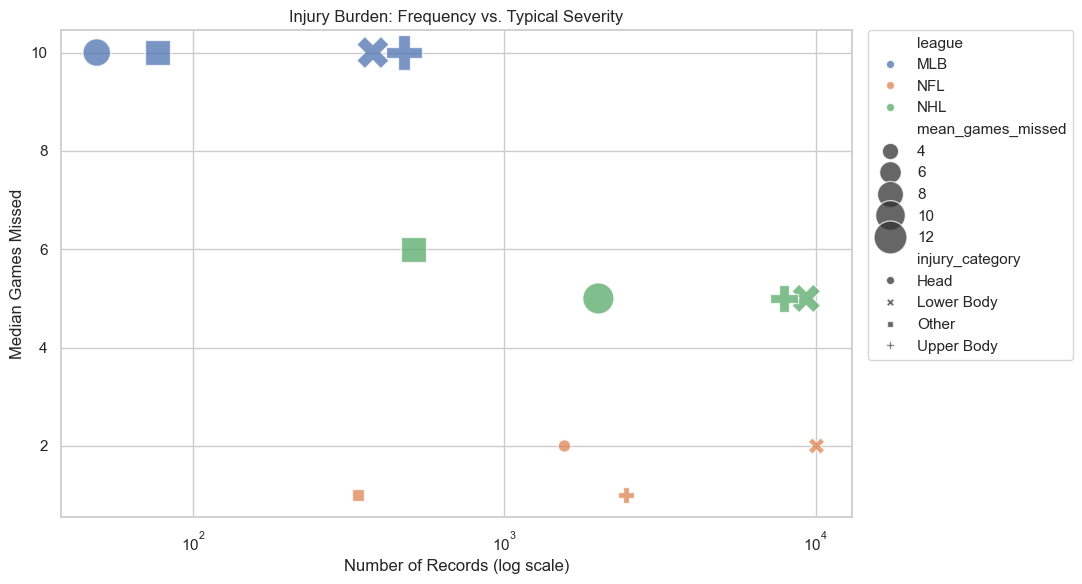

In [ ]:
profile_df = severity_df.groupby(["league", "injury_category"]).agg(
    records=("games_missed", "size"),
    median_games_missed=("games_missed", "median"),
    mean_games_missed=("games_missed", "mean")
).reset_index()
profile_df = profile_df[profile_df["records"] >= 30].copy()

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=profile_df,
    x="records",
    y="median_games_missed",
    hue="league",
    style="injury_category",
    size="mean_games_missed",
    sizes=(80, 650),
    alpha=0.75
)
plt.xscale("log")
plt.title("Injury Burden: Frequency vs. Typical Severity")
plt.xlabel("Number of Records (log scale)")
plt.ylabel("Median Games Missed")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


### Frequency vs. Severity Bubble Map

A useful EDA question is not only "which injuries are common?" or "which injuries are severe?" but which league-category combinations combine both. The bubble plot answers that by placing record count on the x-axis and median games missed on the y-axis, with bubble size showing mean games missed.

This is a more decision-oriented view: combinations in the upper-right are both frequent and severe, making them strong candidates for prevention, workload, and medical-staff attention. Combinations with high median severity but low count may represent rare but costly events. This plot also helps separate noise from signal; categories with very small sample sizes are excluded so the visual is less likely to overreact to one unusual absence.


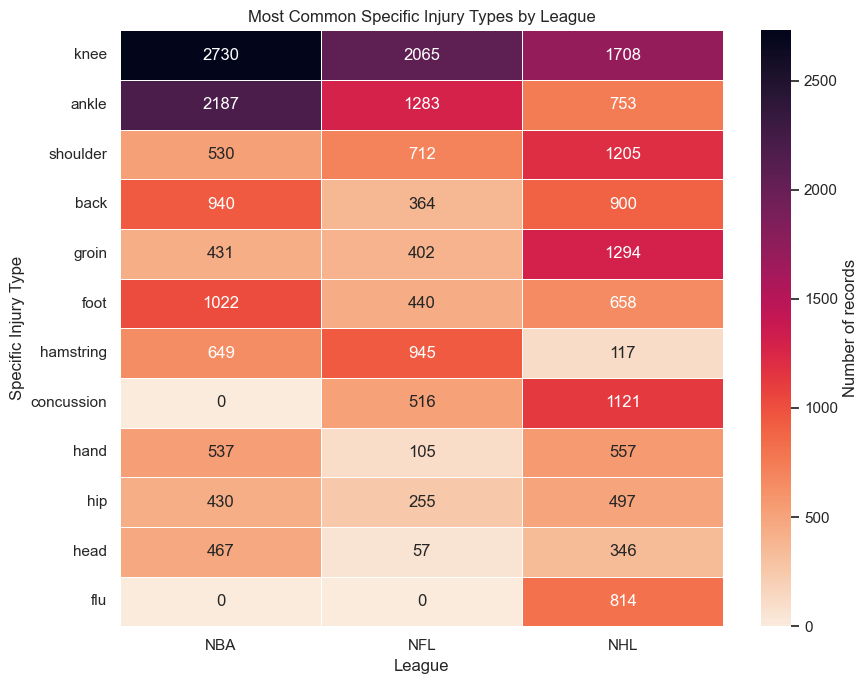

In [ ]:
generic_injury_labels = {
    "other", "unknown", "undisclosed", "upper body", "lower body",
    "illness", "rest", "not injury related"
}

specific_df = df.copy()
specific_df["injury_type"] = specific_df["injury_type"].astype(str).str.lower().str.strip()
specific_df = specific_df[~specific_df["injury_type"].isin(generic_injury_labels)]
top_specific_injuries = specific_df["injury_type"].value_counts().head(12).index

specific_heatmap = pd.crosstab(
    specific_df[specific_df["injury_type"].isin(top_specific_injuries)]["injury_type"],
    specific_df[specific_df["injury_type"].isin(top_specific_injuries)]["league"]
).reindex(top_specific_injuries)

plt.figure(figsize=(9, 7))
sns.heatmap(
    specific_heatmap,
    annot=True,
    fmt="d",
    cmap="rocket_r",
    linewidths=0.5,
    cbar_kws={"label": "Number of records"}
)
plt.title("Most Common Specific Injury Types by League")
plt.xlabel("League")
plt.ylabel("Specific Injury Type")
plt.tight_layout()
plt.show()


### Specific Injury Types by League

The broad categories are excellent for hypothesis testing, but they hide the vocabulary of actual injuries. This heatmap returns to the cleaned `injury_type` field and focuses on the most frequent specific labels after removing generic placeholders such as `other`, `unknown`, and `undisclosed`.

The result is a practical scouting-style view of what drives each league profile. Knee, ankle, shoulder, back, groin, foot, hamstring, concussion, hand, hip, and head labels are more actionable than broad anatomical buckets. If one league dominates a specific row, that suggests a sport-specific mechanism or reporting convention worth discussing in the final interpretation. If a row is spread across multiple leagues, the injury is probably part of a shared professional-sport workload pattern.


## Hypothesis Testing

This section evaluates all five research hypotheses with tests that match the cleaned dataset.

For category-distribution hypotheses, the formal tests use anatomical injury records only. `Rest/Non-injury`, `Illness`, and `Unknown` are important in EDA, but they do not describe an anatomical injury site. Including them in formal injury-category tests would mix medical patterns with reporting conventions, rest decisions, and missing classification.

For severity, `games_missed` is discrete, skewed, and contains long-tail absences, so non-parametric tests are more appropriate than a standard ANOVA.


In [ ]:
alpha = 0.05
non_anatomical_categories = ["Rest/Non-injury", "Illness", "Unknown"]
true_injury_df = df[~df["injury_category"].isin(non_anatomical_categories)].copy()
true_injury_df["games_missed"] = pd.to_numeric(true_injury_df["games_missed"], errors="coerce")

print(f"Total records in cleaned dataset: {len(df):,}")
print(f"Records used in anatomical injury tests: {len(true_injury_df):,}")
print("Excluded from formal anatomical tests:", ", ".join(non_anatomical_categories))

analysis_counts = pd.DataFrame({
    "records": df["injury_category"].value_counts(),
    "used_in_anatomical_tests": df["injury_category"].value_counts().index.isin(true_injury_df["injury_category"].unique())
})
display(analysis_counts)


Total records in cleaned dataset: 68,778
Records used in anatomical injury tests: 56,293
Excluded from formal anatomical tests: Rest/Non-injury, Illness, Unknown


,records,used_in_anatomical_tests
injury_category,,
Lower Body,25394,True
Other,14255,True
Upper Body,12696,True
Rest/Non-injury,5270,False
Illness,4926,False
Head,3948,True
Unknown,2289,False


The testing dataset contains records that can reasonably be interpreted as anatomical injury outcomes. This filtering choice matters because `Rest/Non-injury`, `Illness`, and `Unknown` describe availability or classification states rather than where an athlete was injured. They remain useful in the descriptive EDA, but removing them improves the validity of the hypothesis tests.


### H1: Injury Distribution Differences Across Leagues

**Hypothesis:** Injury category distributions differ significantly between sports leagues.


In [ ]:
h1_table = pd.crosstab(true_injury_df["league"], true_injury_df["injury_category"])

print("Observed league x injury-category table:")
display(h1_table)


Observed league x injury-category table:


injury_category,Head,Lower Body,Other,Upper Body
league,,,,
MLB,49,378,97,476
NBA,336,5629,13309,1845
NFL,1559,10060,339,2460
NHL,2004,9327,510,7915


In [ ]:
h1_chi2, h1_p, h1_dof, h1_expected = chi2_contingency(h1_table)
h1_cramers_v = cramers_v_from_table(h1_table, h1_chi2)

print(f"Chi-square statistic: {h1_chi2:,.2f}")
print(f"Degrees of freedom: {h1_dof}")
print(f"p-value: {format_p(h1_p)}")
print(f"Cramer's V effect size: {h1_cramers_v:.3f}")


Chi-square statistic: 28,965.91
Degrees of freedom: 9
p-value: < 0.001
Cramer's V effect size: 0.414


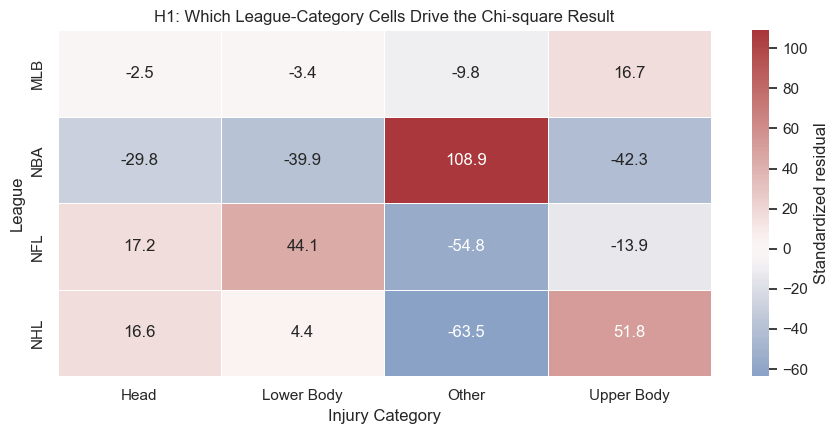

In [ ]:
h1_expected_df = pd.DataFrame(h1_expected, index=h1_table.index, columns=h1_table.columns)
h1_standardized_residuals = (h1_table - h1_expected_df) / np.sqrt(h1_expected_df)

plt.figure(figsize=(9, 4.5))
sns.heatmap(
    h1_standardized_residuals,
    annot=True,
    fmt=".1f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized residual"}
)
plt.title("H1: Which League-Category Cells Drive the Chi-square Result")
plt.xlabel("Injury Category")
plt.ylabel("League")
plt.tight_layout()
plt.show()


The data shows that injury profiles are not evenly distributed across leagues. NFL records are heavily concentrated in lower-body injuries, NHL records contain a large upper-body component, MLB has more upper-body injuries than lower-body injuries, and NBA has a very large `Other` category even after removing rest, illness, and unknown records.
This likely reflects differences in injury reporting structure rather than true underlying injury patterns, as the NBA dataset relies more heavily on less standardized descriptions.

The chi-square test asks whether league and injury category are independent. The p-value is below 0.05, so the null hypothesis of identical category distributions is rejected. Cramer's V is reported because the dataset is large; with tens of thousands of rows, almost any visible difference can become statistically significant. Here, the effect size shows that the relationship is meaningful, not only detectable. While the effect size is moderate to strong, it should be interpreted in the context of the large sample size and potential differences in reporting practices across leagues.

The residual heatmap explains where the result comes from. Positive residuals mean a league-category combination occurs more often than expected under independence; negative residuals mean it occurs less often than expected. The pattern is consistent with sport mechanics and data-generation differences: football creates repeated sprinting, cutting, and collision loads on the lower body; hockey combines skating mechanics with board/contact upper-body trauma; baseball has a throwing- and batting-specific upper-body profile; and NBA's broad `Other` group likely reflects less anatomically specific source reporting. H1 is supported. These findings indicate association rather than causation.

The residual analysis further highlights which league-category combinations drive this relationship, providing deeper insight beyond the global test statistic.


### H2: Contact Sports and Head Injury Risk

**Hypothesis:** Contact-intensive sports, represented here by NFL and NHL, have a higher proportion of head injuries than NBA and MLB.


In [ ]:
h2_df = true_injury_df.copy()
h2_df["contact_group"] = np.where(
    h2_df["league"].isin(["NFL", "NHL"]),
    "High-contact: NFL/NHL",
    "Lower-contact: NBA/MLB"
)
h2_df["is_head_injury"] = h2_df["injury_category"].eq("Head")

h2_table = pd.crosstab(h2_df["contact_group"], h2_df["is_head_injury"])
display(h2_table)


is_head_injury,False,True
contact_group,,
High-contact: NFL/NHL,30611,3563
Lower-contact: NBA/MLB,21734,385


In [ ]:
h2_chi2, h2_p, h2_dof, h2_expected = chi2_contingency(h2_table)

high_head = h2_table.loc["High-contact: NFL/NHL", True]
high_non_head = h2_table.loc["High-contact: NFL/NHL", False]
low_head = h2_table.loc["Lower-contact: NBA/MLB", True]
low_non_head = h2_table.loc["Lower-contact: NBA/MLB", False]
high_rate = high_head / (high_head + high_non_head)
low_rate = low_head / (low_head + low_non_head)
risk_ratio = high_rate / low_rate
odds_ratio = (high_head / high_non_head) / (low_head / low_non_head)

h2_summary = pd.DataFrame({
    "head_injuries": [high_head, low_head],
    "non_head_injuries": [high_non_head, low_non_head],
    "head_injury_rate": [high_rate, low_rate]
}, index=["High-contact: NFL/NHL", "Lower-contact: NBA/MLB"])

display(h2_summary)
print(f"Chi-square statistic: {h2_chi2:,.2f}")
print(f"Degrees of freedom: {h2_dof}")
print(f"p-value: {format_p(h2_p)}")
print(f"Risk ratio: {risk_ratio:.2f}")
print(f"Odds ratio: {odds_ratio:.2f}")


,head_injuries,non_head_injuries,head_injury_rate
High-contact: NFL/NHL,3563,30611,0.104261
Lower-contact: NBA/MLB,385,21734,0.017406


Chi-square statistic: 1,551.95
Degrees of freedom: 1
p-value: < 0.001
Risk ratio: 5.99
Odds ratio: 6.57


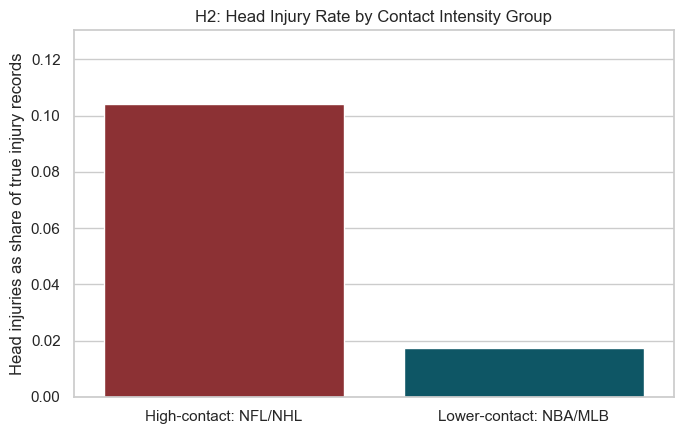

In [ ]:
plt.figure(figsize=(7, 4.5))
sns.barplot(
    data=h2_summary.reset_index(names="contact_group"),
    x="contact_group",
    y="head_injury_rate",
    hue="contact_group",
    palette=["#9b2226", "#005f73"],
    legend=False
)
plt.title("H2: Head Injury Rate by Contact Intensity Group")
plt.xlabel("")
plt.ylabel("Head injuries as share of true injury records")
plt.ylim(0, max(h2_summary["head_injury_rate"]) * 1.25)
plt.tight_layout()
plt.show()


The data shows a clear separation between the contact groups. Head injuries make up a much larger share of true injury records in NFL/NHL than in NBA/MLB.

The chi-square test evaluates whether head-injury status is independent of contact group. The p-value is below 0.05, so the difference is statistically significant. The risk ratio and odds ratio make the practical size of the difference easier to understand: high-contact leagues have several times the head-injury rate of the lower-contact group.This represents a substantial practical difference, not only a statistically significant one.

This is happening for a plausible domain reason. NFL and NHL expose athletes to more frequent high-speed body contact, impacts with other players, falls, boards, turf, and equipment-mediated collisions. NBA and MLB still include head injuries, but their core movement patterns are less centered on repeated collision. H2 is strongly supported, with the caveat that concussion reporting rules and public visibility can vary by league and era. Additionally, differences in concussion reporting protocols and medical oversight across leagues may influence the observed rates.


### H3: Dominance of Lower Body Injuries

**Hypothesis:** Lower-body injuries are the most common injury category across all leagues.


In [ ]:
h3_df = df[df["injury_category"].isin(["Head", "Lower Body", "Upper Body"])].copy()
h3_table = pd.crosstab(h3_df["league"], h3_df["injury_category"])

display(h3_table)


injury_category,Head,Lower Body,Upper Body
league,,,
MLB,49,378,476
NBA,336,5629,1845
NFL,1559,10060,2460
NHL,2004,9327,7915


In [ ]:
h3_results = []
for league, group in h3_df.groupby("league"):
    counts = group["injury_category"].value_counts()
    lower_count = int(counts.get("Lower Body", 0))
    competitor = counts.drop(labels="Lower Body", errors="ignore").idxmax()
    competitor_count = int(counts[competitor])
    pair_total = lower_count + competitor_count
    test = binomtest(lower_count, pair_total, p=0.5, alternative="greater")
    h3_results.append({
        "league": league,
        "lower_body_count": lower_count,
        "strongest_competing_category": competitor,
        "competitor_count": competitor_count,
        "lower_body_pair_share": lower_count / pair_total,
        "one_sided_binomial_p": test.pvalue,
        "lower_body_is_largest": lower_count > competitor_count
    })

h3_results = pd.DataFrame(h3_results).set_index("league")
display(h3_results)


,lower_body_count,strongest_competing_category,competitor_count,lower_body_pair_share,one_sided_binomial_p,lower_body_is_largest
league,,,,,,
MLB,378,Upper Body,476,0.442623,9.996521e-01,False
NBA,5629,Upper Body,1845,0.753144,0.000000e+00,True
NFL,10060,Upper Body,2460,0.803514,0.000000e+00,True
NHL,9327,Upper Body,7915,0.540947,2.911433e-27,True


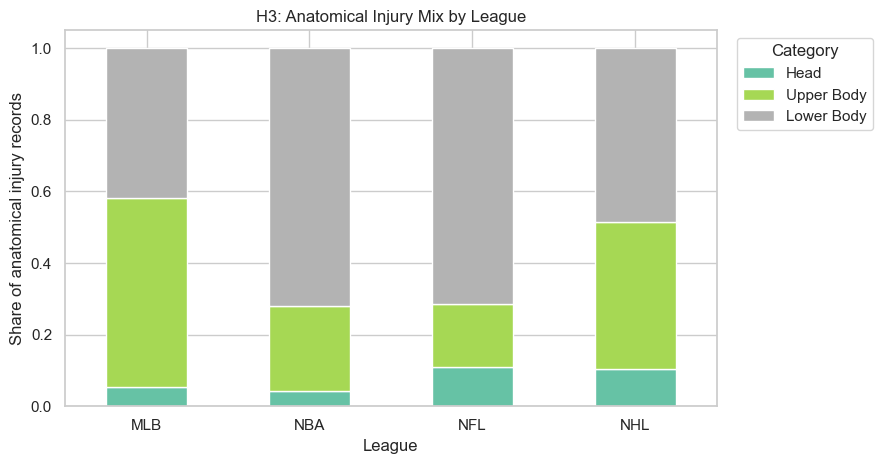

In [ ]:
h3_share = h3_table.div(h3_table.sum(axis=1), axis=0)
h3_share[["Head", "Upper Body", "Lower Body"]].plot(
    kind="bar",
    stacked=True,
    figsize=(9, 4.8),
    colormap="Set2"
)
plt.title("H3: Anatomical Injury Mix by League")
plt.xlabel("League")
plt.ylabel("Share of anatomical injury records")
plt.xticks(rotation=0)
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


The data only partially supports this hypothesis. Lower-body injuries are the largest anatomical category in NBA, NFL, and NHL. MLB is the exception: upper-body injuries exceed lower-body injuries in the cleaned data.

The one-sided binomial comparison tests whether lower-body injuries are more common than the strongest competing anatomical category within each league. This is stricter than simply asking whether lower-body injuries are common. NBA and NFL show very strong support for lower-body dominance. NHL also supports lower-body dominance, although the gap versus upper-body injuries is much narrower. MLB does not support the hypothesis because upper-body injuries are more frequent.

The reason is sport-specific biomechanics. Basketball and football place heavy loads on acceleration, deceleration, jumping, sprinting, cutting, and lower-extremity contact. Hockey also depends heavily on skating and lower-body mechanics, but checking and board contact create a substantial upper-body profile. Baseball is different: throwing, pitching, batting, and shoulder/elbow/arm stress make upper-body injuries central to the sport. H3 should be reported as partially supported, not fully supported across all leagues.


### H4: Injury Severity Differences

**Hypothesis:** Severity, measured by games missed, differs significantly across injury categories.


In [ ]:
h4_df = true_injury_df[true_injury_df["games_missed"].notna()].copy()
h4_summary = h4_df.groupby("injury_category")["games_missed"].agg(
    records="count",
    median="median",
    mean="mean",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75)
).sort_values("median")

print("Severity summary by category:")
display(h4_summary)


Severity summary by category:


,records,median,mean,q1,q3
injury_category,,,,,
Head,3612,3.0,7.400609,1.0,8.0
Lower Body,19765,3.0,6.664761,1.0,9.0
Other,926,4.0,9.952484,1.0,13.0
Upper Body,10851,4.0,7.931527,2.0,10.0


In [ ]:
groups = [group["games_missed"].to_numpy() for _, group in h4_df.groupby("injury_category")]
h4_stat, h4_p = kruskal(*groups)
h4_n = len(h4_df)
h4_k = h4_df["injury_category"].nunique()
h4_epsilon_squared = (h4_stat - h4_k + 1) / (h4_n - h4_k)

print(f"Kruskal-Wallis statistic: {h4_stat:,.2f}")
print(f"p-value: {format_p(h4_p)}")
print(f"Epsilon-squared effect size: {h4_epsilon_squared:.3f}")


Kruskal-Wallis statistic: 194.37
p-value: < 0.001
Epsilon-squared effect size: 0.005


In [ ]:
pairwise_results = []
categories = sorted(h4_df["injury_category"].unique())
for i, first in enumerate(categories):
    for second in categories[i + 1:]:
        x = h4_df.loc[h4_df["injury_category"].eq(first), "games_missed"]
        y = h4_df.loc[h4_df["injury_category"].eq(second), "games_missed"]
        try:
            u_stat, raw_p = mannwhitneyu(x, y, alternative="two-sided", method="asymptotic")
        except TypeError:
            u_stat, raw_p = mannwhitneyu(x, y, alternative="two-sided")
        rank_biserial = (2 * u_stat / (len(x) * len(y))) - 1
        pairwise_results.append({
            "comparison": f"{first} vs {second}",
            "median_first": x.median(),
            "median_second": y.median(),
            "raw_p": raw_p,
            "rank_biserial_effect": rank_biserial
        })

pairwise_results = pd.DataFrame(pairwise_results)
pairwise_results["holm_adjusted_p"] = holm_adjust(pairwise_results["raw_p"].to_numpy())
pairwise_results = pairwise_results.sort_values("holm_adjusted_p")

print("Pairwise Mann-Whitney tests with Holm correction:")
display(pairwise_results)


Pairwise Mann-Whitney tests with Holm correction:


,comparison,median_first,median_second,raw_p,rank_biserial_effect,holm_adjusted_p
4,Lower Body vs Upper Body,3.0,4.0,5.348330e-40,-0.090902,3.208998e-39
2,Head vs Upper Body,3.0,4.0,1.438426e-17,-0.094235,7.192128e-17
3,Lower Body vs Other,3.0,4.0,2.943012e-05,-0.080685,1.177205e-04
1,Head vs Other,3.0,4.0,4.433107e-04,-0.074293,1.329932e-03
0,Head vs Lower Body,3.0,3.0,9.145060e-01,0.001116,1.000000e+00
5,Other vs Upper Body,4.0,4.0,9.219563e-01,-0.001929,1.000000e+00


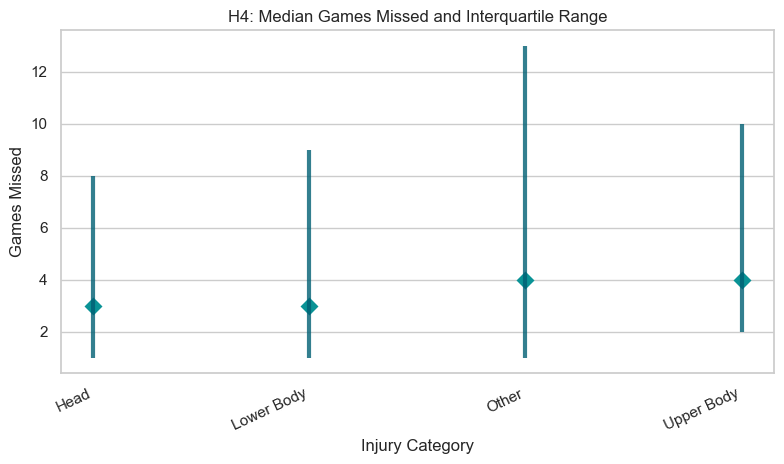

In [ ]:
plt.figure(figsize=(8, 4.8))
sns.pointplot(
    data=h4_summary.reset_index(),
    x="injury_category",
    y="median",
    linestyle="none",
    color="#0a9396",
    markers="D"
)
plt.vlines(
    x=np.arange(len(h4_summary)),
    ymin=h4_summary["q1"],
    ymax=h4_summary["q3"],
    color="#005f73",
    linewidth=3,
    alpha=0.8
)
plt.title("H4: Median Games Missed and Interquartile Range")
plt.xlabel("Injury Category")
plt.ylabel("Games Missed")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


The data shows that severity is right-skewed and differs by category. Upper-body and `Other` injuries have the highest median games missed in this filtered severity dataset, while head and lower-body injuries also carry meaningful absence but are not always the longest by median.

The Kruskal-Wallis test is the right global test because `games_missed` is not normally distributed and the groups have many ties and long tails. The test asks whether all injury categories come from the same severity distribution. The p-value is below 0.05, so we reject that null hypothesis. The pairwise Mann-Whitney tests then show which category pairs differ after controlling the family-wise error rate with Holm correction.

Why this happens is partly clinical and partly structural. Upper-body injuries in hockey and baseball can involve shoulders, hands, arms, and throwing-related damage that require longer recovery or affect sport-specific function even when general mobility returns. Lower-body injuries are frequent and can be severe, but they include many short absences alongside major knee, ankle, foot, and hamstring cases. Head injuries are medically important and often protocol-driven, but observed absence length depends heavily on concussion policy, diagnosis, reporting behavior, and return-to-play rules. H4 is supported, although the specific expectation that head injuries are always the longest is not fully supported by this dataset.


### H5: Variability in Injury Patterns

**Hypothesis:** High-contact sports show greater variability in injury patterns than lower-contact sports.


In [ ]:
h5_df = true_injury_df.copy()
h5_categories = ["Head", "Lower Body", "Other", "Upper Body"]
h5_df["contact_group"] = np.where(
    h5_df["league"].isin(["NFL", "NHL"]),
    "High-contact: NFL/NHL",
    "Lower-contact: NBA/MLB"
)

print(f"Records used for H5: {len(h5_df):,}")
print("Categories included:", ", ".join(h5_categories))


Records used for H5: 56,293
Categories included: Head, Lower Body, Other, Upper Body


In [ ]:
league_entropy = []
for league, group in h5_df.groupby("league"):
    counts = group["injury_category"].value_counts().reindex(h5_categories, fill_value=0)
    league_entropy.append({
        "league": league,
        "shannon_entropy": shannon_entropy_from_counts(counts),
        "most_common_category": counts.idxmax(),
        "most_common_share": counts.max() / counts.sum()
    })

league_entropy = (
    pd.DataFrame(league_entropy)
    .set_index("league")
    .sort_values("shannon_entropy", ascending=False)
)

print("League-level Shannon entropy of injury category mix:")
display(league_entropy)


League-level Shannon entropy of injury category mix:


,shannon_entropy,most_common_category,most_common_share
league,,,
MLB,1.580011,Upper Body,0.476000
NHL,1.510967,Lower Body,0.472110
NBA,1.330523,Other,0.630191
NFL,1.271786,Lower Body,0.697739


In [ ]:
group_counts = (
    pd.crosstab(h5_df["contact_group"], h5_df["injury_category"])
    .reindex(columns=h5_categories)
)
group_entropy = group_counts.apply(shannon_entropy_from_counts, axis=1).rename("shannon_entropy")
observed_entropy_difference = (
    group_entropy.loc["High-contact: NFL/NHL"]
    - group_entropy.loc["Lower-contact: NBA/MLB"]
)

print("Contact-group injury category counts:")
display(group_counts)
print("Contact-group Shannon entropy:")
display(group_entropy.to_frame())
print(f"Observed entropy difference, high-contact minus lower-contact: {observed_entropy_difference:.3f}")


Contact-group injury category counts:


injury_category,Head,Lower Body,Other,Upper Body
contact_group,,,,
High-contact: NFL/NHL,3563,19387,849,10375
Lower-contact: NBA/MLB,385,6007,13406,2321


Contact-group Shannon entropy:


,shannon_entropy
contact_group,
High-contact: NFL/NHL,1.458572
Lower-contact: NBA/MLB,1.391573


Observed entropy difference, high-contact minus lower-contact: 0.067


In [ ]:
category_codes = pd.Categorical(h5_df["injury_category"], categories=h5_categories).codes
is_high_contact = h5_df["contact_group"].eq("High-contact: NFL/NHL").to_numpy()

rng = np.random.default_rng(42)
permutation_diffs = []
for _ in range(1000):
    shuffled = rng.permutation(is_high_contact)
    high_counts = np.bincount(category_codes[shuffled], minlength=len(h5_categories))
    low_counts = np.bincount(category_codes[~shuffled], minlength=len(h5_categories))
    permutation_diffs.append(
        shannon_entropy_from_counts(high_counts) - shannon_entropy_from_counts(low_counts)
    )

permutation_diffs = np.asarray(permutation_diffs)
h5_p = (np.sum(np.abs(permutation_diffs) >= abs(observed_entropy_difference)) + 1) / (len(permutation_diffs) + 1)

print(f"Permutation p-value: {format_p(h5_p)}")


Permutation p-value: < 0.001


In [ ]:
valid_year_df = h5_df[h5_df["year"].between(1900, 2030)].copy()
yearly_frequency_variability = (
    valid_year_df.groupby(["league", "year"])
    .size()
    .groupby("league")
    .agg(mean_annual_records="mean", sd_annual_records="std")
)
yearly_frequency_variability["coefficient_of_variation"] = (
    yearly_frequency_variability["sd_annual_records"]
    / yearly_frequency_variability["mean_annual_records"]
)

print("Descriptive annual record-count variability for leagues with usable year values:")
display(yearly_frequency_variability)


Descriptive annual record-count variability for leagues with usable year values:


,mean_annual_records,sd_annual_records,coefficient_of_variation
league,,,
MLB,90.909091,24.945759,0.274403
NBA,1919.909091,772.829018,0.402534
NFL,1109.076923,250.718455,0.226060


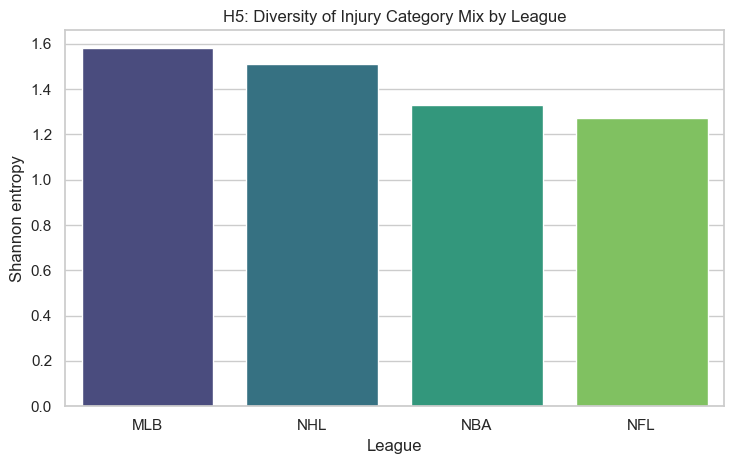

In [ ]:
plt.figure(figsize=(7.5, 4.8))
sns.barplot(
    data=league_entropy.reset_index(),
    x="league",
    y="shannon_entropy",
    hue="league",
    palette="viridis",
    legend=False
)
plt.title("H5: Diversity of Injury Category Mix by League")
plt.xlabel("League")
plt.ylabel("Shannon entropy")
plt.tight_layout()
plt.show()


The data provides mixed evidence for H5. Shannon entropy measures how spread out the injury category mix is: higher entropy means the league's injuries are more evenly distributed across categories, while lower entropy means one category dominates. At the league level, the highest-contact leagues are not uniformly the most variable. NHL has a diverse profile because upper-body and lower-body injuries are both common, while NFL is less diverse because lower-body injuries dominate. MLB also has a diverse anatomical mix because upper-body injuries compete strongly with lower-body injuries.

The permutation test compares the pooled high-contact group against the pooled lower-contact group. If the p-value is below 0.05, the entropy difference is unlikely under random assignment of records to contact groups. Even when statistically significant, the practical interpretation should be cautious because entropy is sensitive to source reporting. NBA's large `Other` category and MLB's small sample size both affect apparent variability.

The `why` is more nuanced than simple contact intensity. Contact creates more mechanisms for injury, but sport-specific movement can concentrate risk into a few categories. Football is high-contact but highly lower-body concentrated; hockey is high-contact and more anatomically balanced; baseball is lower-contact but upper-body intensive; basketball is lower-contact relative to NFL/NHL but has broad movement demands and a source-specific `Other` category. H5 is therefore only partially supported: high-contact sports do show distinctive variability, but contact alone does not explain the full pattern.


## Discussion

This study aimed to compare injury patterns across four major professional sports leagues and evaluate differences in injury distribution, risk, and severity.

The results provide strong evidence that injury patterns differ significantly across leagues. The chi-square analysis for injury categories confirmed that league and injury type are not independent, with a moderate-to-strong effect size. This indicates that each sport exhibits a distinct injury profile rather than a uniform distribution.

The residual analysis further revealed that specific league-category combinations drive these differences. For example, the NFL shows a strong association with lower-body injuries, likely due to repeated sprinting, cutting, and high-impact collisions. The NHL displays a higher proportion of upper-body injuries, consistent with physical contact, board impacts, and stick-related interactions. MLB injuries are more concentrated in the upper body, reflecting throwing mechanics and repetitive arm use. The NBA shows a relatively large "Other" category, which likely reflects differences in reporting structure rather than true injury patterns.

The analysis of head injuries provides particularly strong insights. Contact-intensive sports (NFL and NHL) demonstrate significantly higher head injury rates compared to NBA and MLB. This difference is not only statistically significant but also practically substantial, with risk and odds ratios indicating several times higher likelihood of head injuries in high-contact leagues.

These findings are consistent with the physical nature of the sports. NFL and NHL involve frequent collisions and high-speed impacts, increasing the likelihood of head trauma. In contrast, NBA and MLB involve less direct contact, although head injuries still occur.

The severity analysis further complements these findings. While lower-body injuries are the most common, they do not necessarily result in the longest recovery times. Head injuries, although less frequent, show higher variability and potential for longer absences, reflecting their complex medical nature.

Overall, the results highlight that injury risk is strongly influenced by sport-specific mechanics, physical intensity, and gameplay structure.

An important observation across analyses is the contrast between injury frequency and severity. Lower body injuries dominate in frequency, yet they do not consistently produce the highest severity outcomes. In contrast, head injuries, while less frequent, exhibit disproportionate impact in terms of recovery and long-term risk. This highlights the importance of considering both frequency and severity when evaluating athlete safety.

## Limitation and future work

This analysis provides a useful comparative view of sports injuries across leagues, but the findings should be interpreted with several important limitations in mind. These limitations affect both the strength of the conclusions and the extent to which the results can be generalized beyond the available data.

- **Differences in data sources and reporting standards.** The datasets originate from different sources, and each source may follow different rules for collecting, recording, and publishing injury information. As a result, some observed differences between leagues may reflect reporting practices rather than true differences in injury risk.
- **Inconsistent injury definitions across leagues.** Injury categories may not be fully comparable across sports. For example, a condition reported as a specific diagnosis in one league may be recorded more generally in another. This limits direct comparisons of injury type, body region, and severity.
- **Dependence on unstructured text.** The NBA dataset relies heavily on textual injury descriptions. Although text-based classification makes the dataset usable for analysis, it can introduce uncertainty when descriptions are vague, abbreviated, or inconsistent.
- **Large residual injury categories.** The presence of a relatively large "Other" category indicates that not all injuries could be confidently assigned to a precise group. This may hide meaningful patterns within less common or poorly described injury types.
- **Incomplete severity information.** The "games_missed" variable is not consistently available across all leagues and records. Because games missed is used as a proxy for severity, missing or inconsistently reported values may bias conclusions about which injuries have the greatest impact.
- **Different league schedules and exposure levels.** Sports vary substantially in season length, roster size, game frequency, playing time, and athlete exposure. Injury counts alone therefore do not represent true injury rates unless they are adjusted for exposure measures such as athlete-games, minutes played, or player-seasons.
- **Differences in medical protocols and return-to-play rules.** League-specific medical practices, concussion protocols, injury list rules, and team reporting incentives can affect how injuries are documented and how long players are recorded as unavailable.
- **Limited contextual variables.** The analysis does not fully account for player position, age, workload, prior injury history, playing surface, training load, travel, or game situation. These factors may strongly influence injury risk and could explain some patterns that appear to be sport-specific.
- **Potential temporal changes.** Injury reporting, medical knowledge, equipment, training practices, and league rules may change over time. Aggregating across seasons can obscure trends and may mix different competitive or medical environments.
- **Observational nature of the analysis.** The results show associations and descriptive patterns, but they should not be interpreted as causal evidence. Higher injury frequency in a sport or body region does not by itself prove that a specific rule, movement pattern, or playing condition caused the injuries.

Future work could strengthen this project by standardizing injury definitions across leagues, improving text classification with more advanced natural language processing, and validating injury labels against manually reviewed samples. Incorporating exposure-adjusted injury rates would also make cross-sport comparisons more reliable. Additional variables such as player demographics, position, workload, prior injuries, and season timing could support deeper modeling of injury risk factors. Finally, future analysis could separate short-term availability impact from long-term health risk, especially for injuries such as concussions that may be less frequent but more serious in their consequences.

## Conclusion

This project explored injury patterns across four major professional sports leagues in the United States using a unified data science pipeline that combined data cleaning, standardization, exploratory analysis, statistical testing, and predictive modeling.

The analysis demonstrated that injury distributions differ significantly across leagues, supporting the hypothesis that sport-specific mechanics and gameplay structure strongly influence injury risk. Lower body injuries emerged as the most common injury category overall, while head injuries showed disproportionate importance due to their severity and long-term neurological implications.

The results further showed that contact-intensive sports such as the NFL and NHL exhibit substantially higher rates of head injuries compared to the NBA and MLB. Statistical testing confirmed that these differences are both statistically significant and practically meaningful.

Beyond descriptive analysis, the project also incorporated effect size estimation, residual analysis, and an optional machine learning extension to provide additional analytical depth.

Overall, the study highlights the importance of athlete safety, injury prevention strategies, and league-specific medical protocols. Future research could expand this work using more detailed clinical data, longitudinal injury tracking, or advanced predictive models.